# Blok C — Faktorial 2×2: attention × Modul P

Memperdalam efek faktorial yang sudah dihitung di `analisis_blok_A_klaim_utama.ipynb`
(§A.9). Fokus di sini: **apakah interaksinya konsisten lintas metrik**, dan pada
metrik mana kedua komponen saling melengkapi vs saling menggantikan.

$$\text{efek\_attn} = \tfrac{sel2+sel4}{2} - \tfrac{sel1+sel3}{2}, \quad
\text{efek\_P} = \tfrac{sel3+sel4}{2} - \tfrac{sel1+sel2}{2}, \quad
\text{interaksi} = (sel4-sel3) - (sel2-sel1)$$

Rancangan PURE3, kondisi baku (trust 0,5 · gamma 0,99 · beban 4×), 90 hari.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _analisis_bab5 as A
pd.set_option('display.width', 230); pd.set_option('display.max_columns', 50)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': .3})
HORIZON = '90d'
B = 'master_hybrid_ppo_dgr_90d_cwtfail120pen-2_preffeat_pairout'
A.ARAH_BAIK.update({'gini_UTIL': 'min', 'gini_ANTRE': 'min'})

def nilai(tag, m, lengan=None):
    if m == 'gini_UTIL':  return A.gini_stasiun(tag, 'gini_utilisasi', HORIZON, lengan)
    if m == 'gini_ANTRE': return A.gini_stasiun(tag, 'gini_antrean',   HORIZON, lengan)
    return A.unit_stat(tag, m, HORIZON, lengan)

SEL = {'sel1': f'{B}_noattn_pure3', 'sel2': f'{B}_pure3',
       'sel3': f'{B}_pg0.1_noattn_pure3', 'sel4': f'{B}_pg0.1_pure3'}
print({k: len(nilai(v, 'acc')[2]) for k, v in SEL.items()}, '= n checkpoint per sel')

{'sel1': 3, 'sel2': 3, 'sel3': 3, 'sel4': 3} = n checkpoint per sel


## C.1 — Efek utama & interaksi lintas metrik

Kolom `sifat` menafsirkan interaksi relatif terhadap arah "lebih baik" metrik itu:
**komplementer** = gabungan melampaui jumlah kedua komponen; **substitutif** = gabungan
kurang dari jumlahnya (perannya tumpang tindih).

In [2]:
M = ['gini_UTIL', 'gini_ANTRE', 'gini_wait_pengguna', 'acc', 'wait', 'trust',
     'frac_trust_rendah', 'pct_tepat', 'pct_telat', 'rec_entropy', 'herding', 'flocking',
     'jnpatuh_expost_frac_untung', 'jnpatuh_expost_mean', 'entropi_spklu_pengguna',
     'pref_dalam', 'patuh_bila_pref_tiada']
baris = []
for m in M:
    v = {k: nilai(t, m)[0] for k, t in SEL.items()}
    s1, s2, s3, s4 = v['sel1'], v['sel2'], v['sel3'], v['sel4']
    ea, ep = (s2+s4)/2 - (s1+s3)/2, (s3+s4)/2 - (s1+s2)/2
    it = (s4-s3) - (s2-s1)
    arah = A.ARAH_BAIK.get(m, 'max')
    baik = lambda x: (x < 0) == (arah == 'min')
    sifat = ('-' if abs(it) < 1e-9 else
             ('komplementer' if baik(it) else 'substitutif'))
    baris.append({'metrik': m, 'arah': arah, 'sel1': s1, 'sel2': s2, 'sel3': s3,
                  'sel4': s4, 'efek_attn': ea, 'efek_P': ep, 'interaksi': it,
                  'attn_baik': baik(ea), 'P_baik': baik(ep), 'sifat': sifat,
                  '|inter|/|efek|': abs(it) / max(abs(ea), abs(ep), 1e-12)})
fak = pd.DataFrame(baris).set_index('metrik')
display(fak.round(4))

,arah,sel1,sel2,sel3,sel4,efek_attn,efek_P,interaksi,attn_baik,P_baik,sifat,|inter|/|efek|
metrik,,,,,,,,,,,,
gini_UTIL,min,0.0289,0.0393,0.0521,0.0206,-0.0106,0.0023,-0.0419,True,False,komplementer,3.9563
gini_ANTRE,min,0.0929,0.1216,0.1447,0.0690,-0.0235,-0.0004,-0.1044,True,True,komplementer,4.4438
gini_wait_pengguna,min,0.3870,0.4003,0.3975,0.4085,0.0121,0.0093,-0.0023,False,False,komplementer,0.1903
acc,max,0.6700,0.7021,0.7034,0.7194,0.0240,0.0253,-0.0160,True,True,substitutif,0.6320
wait,min,95.9557,89.6613,84.1083,66.2480,-12.0773,-17.6303,-11.5660,True,True,komplementer,0.6560
trust,max,0.3666,0.3935,0.3960,0.4348,0.0328,0.0353,0.0118,True,True,komplementer,0.3350
frac_trust_rendah,min,0.4010,0.3416,0.3361,0.2427,-0.0764,-0.0819,-0.0340,True,True,komplementer,0.4150
pct_tepat,max,28.2528,34.9973,34.6041,37.7053,4.9229,4.5297,-3.6433,True,True,substitutif,0.7401
pct_telat,min,27.2745,23.8835,23.3575,18.4151,-4.1667,-4.6927,-1.5514,True,True,komplementer,0.3306


In [3]:
print('Ringkasan arah efek:\n')
print(f"  attention memperbaiki : {int(fak['attn_baik'].sum())}/{len(fak)} metrik")
print(f"  Modul P memperbaiki   : {int(fak['P_baik'].sum())}/{len(fak)} metrik")
print(f"  interaksi komplementer: {(fak['sifat']=='komplementer').sum()}/{len(fak)} metrik")
print()
print('Metrik dgn interaksi MENDOMINASI efek utama (|interaksi| > |efek terbesar|):')
dom = fak[fak['|inter|/|efek|'] > 1].sort_values('|inter|/|efek|', ascending=False)
for m, r in dom.iterrows():
    print(f"   {m:28s} rasio={r['|inter|/|efek|']:5.2f}  {r['sifat']}")
print()
print('>> Di metrik ini, komponen TIDAK dapat dinilai sendiri-sendiri:')
print('   pengaruh gabungannya lebih besar dari jumlah pengaruh terpisahnya.')

Ringkasan arah efek:

  attention memperbaiki : 15/17 metrik
  Modul P memperbaiki   : 15/17 metrik
  interaksi komplementer: 13/17 metrik

Metrik dgn interaksi MENDOMINASI efek utama (|interaksi| > |efek terbesar|):
   jnpatuh_expost_frac_untung   rasio= 5.58  komplementer
   gini_ANTRE                   rasio= 4.44  komplementer
   gini_UTIL                    rasio= 3.96  komplementer
   pref_dalam                   rasio= 2.62  substitutif
   jnpatuh_expost_mean          rasio= 1.91  komplementer

>> Di metrik ini, komponen TIDAK dapat dinilai sendiri-sendiri:
   pengaruh gabungannya lebih besar dari jumlah pengaruh terpisahnya.


## C.2 — Pola urutan sel

Dua pola berbeda muncul, dan pembedanya penting:

- **`sel1 < sel2 ≈ sel3 < sel4`** — aditif: tiap komponen membantu sendiri, gabungan
  paling baik.
- **`sel4 < sel1 < sel2 < sel3`** — komplementer murni: komponen sendirian
  **memperburuk**, hanya gabungan yang membantu.

In [4]:
baris = []
for m in M:
    v = {k: nilai(t, m)[0] for k, t in SEL.items()}
    arah = A.ARAH_BAIK.get(m, 'max')
    urut = sorted(v, key=lambda k: v[k] if arah == 'min' else -v[k])
    baris.append({'metrik': m, 'urutan (terbaik→terburuk)': ' < '.join(urut),
                  'sel4 peringkat': urut.index('sel4') + 1,
                  'sel1 peringkat': urut.index('sel1') + 1})
ur = pd.DataFrame(baris).set_index('metrik')
display(ur)
print(f"sel4 peringkat-1 pada {(ur['sel4 peringkat']==1).sum()}/{len(ur)} metrik")
print(f"sel1 peringkat-1 pada {(ur['sel1 peringkat']==1).sum()}/{len(ur)} metrik")

,urutan (terbaik→terburuk),sel4 peringkat,sel1 peringkat
metrik,,,
gini_UTIL,sel4 < sel1 < sel2 < sel3,1,2
gini_ANTRE,sel4 < sel1 < sel2 < sel3,1,2
gini_wait_pengguna,sel1 < sel3 < sel2 < sel4,4,1
acc,sel4 < sel3 < sel2 < sel1,1,4
wait,sel4 < sel3 < sel2 < sel1,1,4
trust,sel4 < sel3 < sel2 < sel1,1,4
frac_trust_rendah,sel4 < sel3 < sel2 < sel1,1,4
pct_tepat,sel4 < sel2 < sel3 < sel1,1,4
pct_telat,sel4 < sel3 < sel2 < sel1,1,4


sel4 peringkat-1 pada 15/17 metrik
sel1 peringkat-1 pada 1/17 metrik


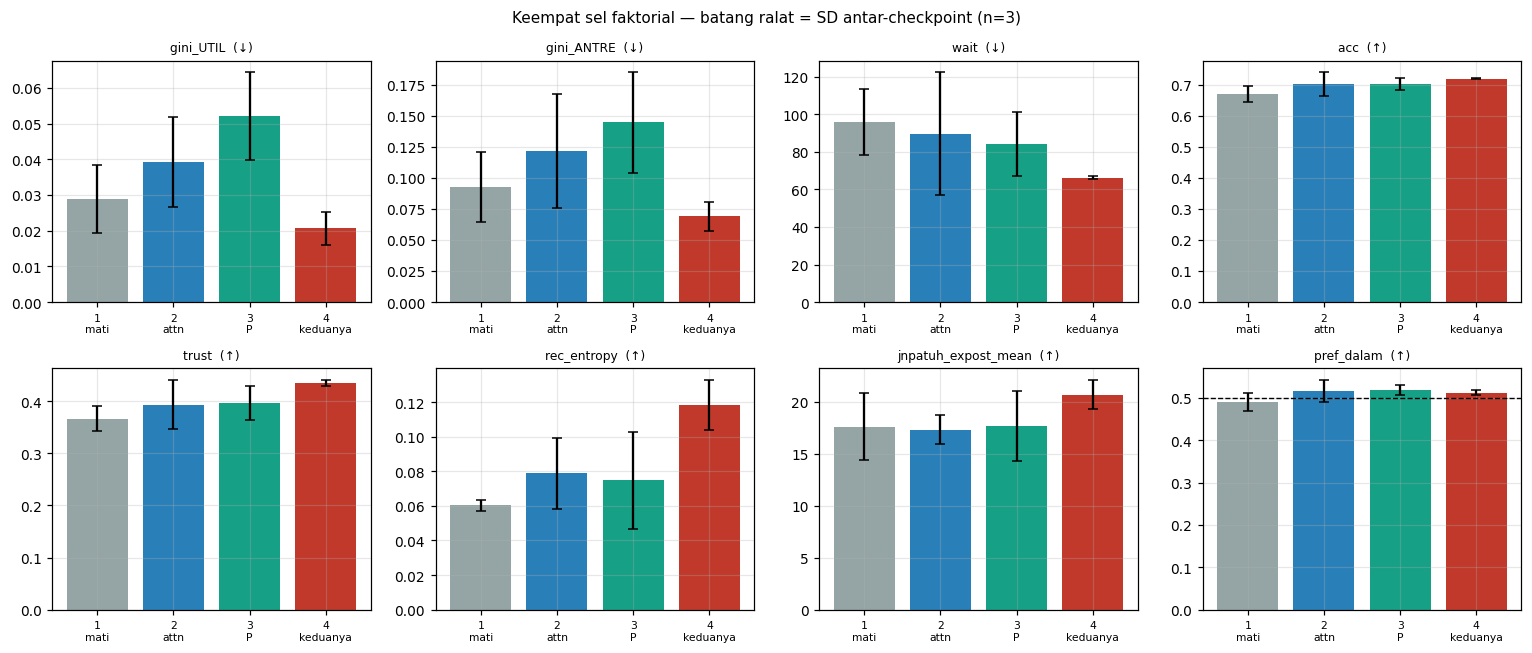

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
tampil = ['gini_UTIL', 'gini_ANTRE', 'wait', 'acc', 'trust', 'rec_entropy',
          'jnpatuh_expost_mean', 'pref_dalam']
for ax, m in zip(axes.ravel(), tampil):
    v = [nilai(SEL[k], m)[0] for k in ['sel1', 'sel2', 'sel3', 'sel4']]
    e = [nilai(SEL[k], m)[1] for k in ['sel1', 'sel2', 'sel3', 'sel4']]
    warna = ['#95a5a6', '#2980b9', '#16a085', '#c0392b']
    ax.bar(range(4), v, yerr=e, capsize=3, color=warna)
    ax.set_xticks(range(4)); ax.set_xticklabels(['1\nmati', '2\nattn', '3\nP', '4\nkeduanya'],
                                                fontsize=7)
    arah = A.ARAH_BAIK.get(m, 'max')
    ax.set_title(f"{m}  ({'↓' if arah=='min' else '↑'})", fontsize=8)
    if m == 'pref_dalam':
        ax.axhline(0.5, color='k', ls='--', lw=.9)
plt.suptitle('Keempat sel faktorial — batang ralat = SD antar-checkpoint (n=3)', fontsize=10)
plt.tight_layout(); plt.show()

## C.3 — Batas klaim

Dengan n=3 checkpoint per sel, keterpisahan rentang sulit dicapai. Sel berikut memeriksa
pasangan mana yang perbedaannya konsisten di seluruh checkpoint.

In [6]:
baris = []
for m in M:
    for a, b in [('sel4', 'sel1'), ('sel4', 'sel2'), ('sel4', 'sel3'),
                 ('sel2', 'sel1'), ('sel3', 'sel1')]:
        va, vb = nilai(SEL[a], m)[2], nilai(SEL[b], m)[2]
        pisah = va.max() < vb.min() or vb.max() < va.min()
        baris.append({'metrik': m, 'pasangan': f'{a} vs {b}', 'terpisah': pisah})
kp = pd.DataFrame(baris)
piv = kp.pivot(index='metrik', columns='pasangan', values='terpisah')
display(piv)
print(f"\nTotal pasangan terpisah: {kp['terpisah'].sum()} dari {len(kp)}")
print('\nPer pasangan:')
for p, g in kp.groupby('pasangan'):
    m = sorted(g[g['terpisah']]['metrik'])
    print(f"  {p:14s} {len(m):2d} metrik" + (f"  -> {', '.join(m[:4])}" if m else ''))
print()
print('>> Perbedaan sel4 paling konsisten terhadap sel1; terhadap sel2/sel3 jauh lebih')
print('   sedikit. Klaim antar-sel harus disandarkan pada dinamika pelatihan (Blok G),')
print('   bukan pada sebaran hasil semata.')

pasangan,sel2 vs sel1,sel3 vs sel1,sel4 vs sel1,sel4 vs sel2,sel4 vs sel3
metrik,,,,,
acc,False,False,True,False,False
entropi_spklu_pengguna,False,False,True,False,False
flocking,False,False,True,False,False
frac_trust_rendah,False,False,True,False,False
gini_ANTRE,False,False,False,False,True
gini_UTIL,False,False,False,False,True
gini_wait_pengguna,False,False,False,False,False
herding,False,False,True,False,False
jnpatuh_expost_frac_untung,False,False,False,False,False



Total pasangan terpisah: 13 dari 85

Per pasangan:
  sel2 vs sel1    0 metrik
  sel3 vs sel1    0 metrik
  sel4 vs sel1   11 metrik  -> acc, entropi_spklu_pengguna, flocking, frac_trust_rendah
  sel4 vs sel2    0 metrik
  sel4 vs sel3    2 metrik  -> gini_ANTRE, gini_UTIL

>> Perbedaan sel4 paling konsisten terhadap sel1; terhadap sel2/sel3 jauh lebih
   sedikit. Klaim antar-sel harus disandarkan pada dinamika pelatihan (Blok G),
   bukan pada sebaran hasil semata.
